In [1]:
#Installation of Pre-files

In [2]:
pip install --upgrade pip

In [3]:
pip install --upgrade pip

In [4]:
pip install cufflinks

Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install --upgrade mplfinance

Note: you may need to restart the kernel to use updated packages.


In [6]:
#Installation Completed(If not done)

In [1]:
#importing libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline


from matplotlib import *
import seaborn as sns

In [2]:
# Inputting raw data files and confirming the data
silver_ask=pd.read_csv("GBPNOK_5 Mins_Ask_2025.08.01_2025.09.30.csv")
silver_bid=pd.read_csv("XAGUSD_5 Mins_Bid_2023.01.01_2023.06.30.csv")
print('Ask_data')
print(silver_ask.head(3))
print(silver_ask.tail(3))
print('Bid_data')
print(silver_bid.head(3))
print(silver_bid.tail(3))

Ask_data
            Time (UTC)    Open    High     Low   Close  Volume 
0  2023.01.02 23:00:00  24.102  24.125  24.083  24.125    0.351
1  2023.01.02 23:05:00  24.094  24.188  24.094  24.141    1.155
2  2023.01.02 23:10:00  24.143  24.148  24.022  24.027    0.882
                Time (UTC)    Open    High     Low   Close  Volume 
35217  2023.06.30 20:45:00  22.781  22.781  22.776  22.776   0.4212
35218  2023.06.30 20:50:00  22.776  22.797  22.774  22.786   0.6836
35219  2023.06.30 20:55:00  22.786  22.811  22.786  22.811   0.3712
Bid_data
            Time (UTC)    Open    High     Low   Close  Volume 
0  2023.01.02 23:00:00  24.036  24.059  24.017  24.059   0.3480
1  2023.01.02 23:05:00  24.064  24.130  24.064  24.092   1.8458
2  2023.01.02 23:10:00  24.094  24.098  23.972  23.977   0.9030
                Time (UTC)    Open    High     Low   Close  Volume 
35217  2023.06.30 20:45:00  22.751  22.751  22.746  22.746    0.069
35218  2023.06.30 20:50:00  22.746  22.761  22.736  22.756    

In [3]:


#Ask and Bid files information as entries, column, or memory taken
print('Ask information')
silver_ask.info()
print('Bid information')
silver_bid.info()
      

Ask information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35220 entries, 0 to 35219
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Time (UTC)  35220 non-null  object 
 1   Open        35220 non-null  float64
 2   High        35220 non-null  float64
 3   Low         35220 non-null  float64
 4   Close       35220 non-null  float64
 5   Volume      35220 non-null  float64
dtypes: float64(5), object(1)
memory usage: 1.6+ MB
Bid information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35220 entries, 0 to 35219
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Time (UTC)  35220 non-null  object 
 1   Open        35220 non-null  float64
 2   High        35220 non-null  float64
 3   Low         35220 non-null  float64
 4   Close       35220 non-null  float64
 5   Volume      35220 non-null  float64
dtypes: float64(5), object(1)
memory usage: 

In [4]:
# merged data

silver_mrg=silver_bid.merge(silver_ask,left_on='Time (UTC)',right_on='Time (UTC)',how='outer')
silver_mrg

,Time (UTC),Open_x,High_x,Low_x,Close_x,Volume _x,Open_y,High_y,Low_y,Close_y,Volume _y
0,2023.01.02 23:00:00,24.036,24.059,24.017,24.059,0.3480,24.102,24.125,24.083,24.125,0.3510
1,2023.01.02 23:05:00,24.064,24.130,24.064,24.092,1.8458,24.094,24.188,24.094,24.141,1.1550
2,2023.01.02 23:10:00,24.094,24.098,23.972,23.977,0.9030,24.143,24.148,24.022,24.027,0.8820
3,2023.01.02 23:15:00,23.977,23.980,23.938,23.980,0.8940,24.026,24.028,23.986,24.028,0.8940
4,2023.01.02 23:20:00,23.978,24.024,23.976,24.023,0.8880,24.026,24.073,24.023,24.073,0.9044
...,...,...,...,...,...,...,...,...,...,...,...
35215,2023.06.30 20:35:00,22.752,22.752,22.741,22.746,0.2752,22.782,22.782,22.771,22.776,1.8002
35216,2023.06.30 20:40:00,22.736,22.751,22.736,22.746,0.1410,22.775,22.781,22.775,22.776,0.7568
35217,2023.06.30 20:45:00,22.751,22.751,22.746,22.746,0.0690,22.781,22.781,22.776,22.776,0.4212
35218,2023.06.30 20:50:00,22.746,22.761,22.736,22.756,0.2160,22.776,22.797,22.774,22.786,0.6836


In [5]:
# rename columns(bcz merging files cause default changing to _x and _y)

silver_mrg.columns = ['local time', 'open_bid', 'high_bid', 'low_bid', 'close_bid', 'volume_bid', 
                   'open_ask', 'high_ask', 'low_ask', 'close_ask', 'volume_ask']

In [6]:
silver_mrg.head()

,local time,open_bid,high_bid,low_bid,close_bid,volume_bid,open_ask,high_ask,low_ask,close_ask,volume_ask
0,2023.01.02 23:00:00,24.036,24.059,24.017,24.059,0.3480,24.102,24.125,24.083,24.125,0.3510
1,2023.01.02 23:05:00,24.064,24.130,24.064,24.092,1.8458,24.094,24.188,24.094,24.141,1.1550
2,2023.01.02 23:10:00,24.094,24.098,23.972,23.977,0.9030,24.143,24.148,24.022,24.027,0.8820
3,2023.01.02 23:15:00,23.977,23.980,23.938,23.980,0.8940,24.026,24.028,23.986,24.028,0.8940
4,2023.01.02 23:20:00,23.978,24.024,23.976,24.023,0.8880,24.026,24.073,24.023,24.073,0.9044


In [7]:
# Saving the file on the computer
file_obj2= open('silver_mrg.csv', 'w')
silver_mrg.to_csv('silver_mrg.csv',encoding='utf-8', index=False)
file_obj2.close()

In [8]:
silver_mrg=[]
silver_mrg

[]

In [9]:
silver=pd.read_csv('silver_mrg.csv', low_memory=False, sep=',')

In [10]:
#Adding Delta to all the colum(difference between the ask and bid of ALL column)
silver["volume_delta"] = silver["volume_ask"] - silver["volume_bid"]
silver["volume_delta_abs"] = (silver["volume_ask"] - silver["volume_bid"]).abs()




In [11]:
silver["open_delta"] = silver["open_ask"]  - silver["open_bid"]
silver["high_delta"] = silver["high_ask"]  - silver["high_bid"]
silver["low_delta"]  = silver["low_ask"]   - silver["low_bid"]
silver["close_delta"]= silver["close_ask"] - silver["close_bid"]


In [12]:
silver.describe()

,open_bid,high_bid,low_bid,close_bid,volume_bid,open_ask,high_ask,low_ask,close_ask,volume_ask,volume_delta,volume_delta_abs,open_delta,high_delta,low_delta,close_delta
count,35220.000000,35220.000000,35220.000000,35220.000000,35220.000000,35220.000000,35220.000000,35220.000000,35220.000000,35220.000000,35220.000000,35220.000000,35220.000000,35220.000000,35220.000000,35220.000000
mean,23.357365,23.374611,23.338437,23.357367,8.283187,23.387577,23.404824,23.368703,23.387501,35.095338,26.812151,26.908678,0.030212,0.030212,0.030266,0.030134
std,1.368781,1.368825,1.368926,1.368867,8.976407,1.368779,1.368797,1.368944,1.368861,39.024921,33.422609,33.344942,0.003245,0.003380,0.005014,0.003851
min,19.893000,19.914000,19.888000,19.893000,0.000000,19.923000,19.944000,19.918000,19.923000,0.000000,-48.791200,0.000000,0.011000,0.018000,0.001000,0.012000
25%,22.421750,22.440000,22.400000,22.421000,2.611050,22.452000,22.470000,22.430000,22.451000,9.467675,5.170550,5.237100,0.030000,0.030000,0.030000,0.030000
50%,23.560000,23.576000,23.543000,23.560000,5.331100,23.590000,23.607000,23.573000,23.590000,22.237450,14.907800,14.937300,0.030000,0.030000,0.030000,0.030000
75%,24.122000,24.144000,24.103000,24.122000,10.686275,24.153000,24.174000,24.133000,24.152000,46.639375,36.154925,36.159175,0.030000,0.030000,0.030000,0.030000
max,26.118000,26.123000,26.098000,26.118000,120.651700,26.148000,26.153000,26.128000,26.148000,365.632200,317.585800,317.585800,0.185000,0.222000,0.409000,0.309000


In [13]:
data=silver.drop(['open_ask','high_ask','low_ask','close_ask'],axis=1)

In [14]:
data.shape

(35220, 13)

In [15]:
data.head()

,local time,open_bid,high_bid,low_bid,close_bid,volume_bid,volume_ask,volume_delta,volume_delta_abs,open_delta,high_delta,low_delta,close_delta
0,2023.01.02 23:00:00,24.036,24.059,24.017,24.059,0.3480,0.3510,0.0030,0.0030,0.066,0.066,0.066,0.066
1,2023.01.02 23:05:00,24.064,24.130,24.064,24.092,1.8458,1.1550,-0.6908,0.6908,0.030,0.058,0.030,0.049
2,2023.01.02 23:10:00,24.094,24.098,23.972,23.977,0.9030,0.8820,-0.0210,0.0210,0.049,0.050,0.050,0.050
3,2023.01.02 23:15:00,23.977,23.980,23.938,23.980,0.8940,0.8940,0.0000,0.0000,0.049,0.048,0.048,0.048
4,2023.01.02 23:20:00,23.978,24.024,23.976,24.023,0.8880,0.9044,0.0164,0.0164,0.048,0.049,0.047,0.050


In [16]:
import datetime

In [17]:
data['Local_time_T']=pd.to_datetime(data['local time'], utc=True)

In [18]:
data=data.drop(['local time'],axis=1)

In [19]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35220 entries, 0 to 35219
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   open_bid          35220 non-null  float64            
 1   high_bid          35220 non-null  float64            
 2   low_bid           35220 non-null  float64            
 3   close_bid         35220 non-null  float64            
 4   volume_bid        35220 non-null  float64            
 5   volume_ask        35220 non-null  float64            
 6   volume_delta      35220 non-null  float64            
 7   volume_delta_abs  35220 non-null  float64            
 8   open_delta        35220 non-null  float64            
 9   high_delta        35220 non-null  float64            
 10  low_delta         35220 non-null  float64            
 11  close_delta       35220 non-null  float64            
 12  Local_time_T      35220 non-null  datetime64[ns, UTC]
dtypes

In [20]:
#graph od price and volume charts

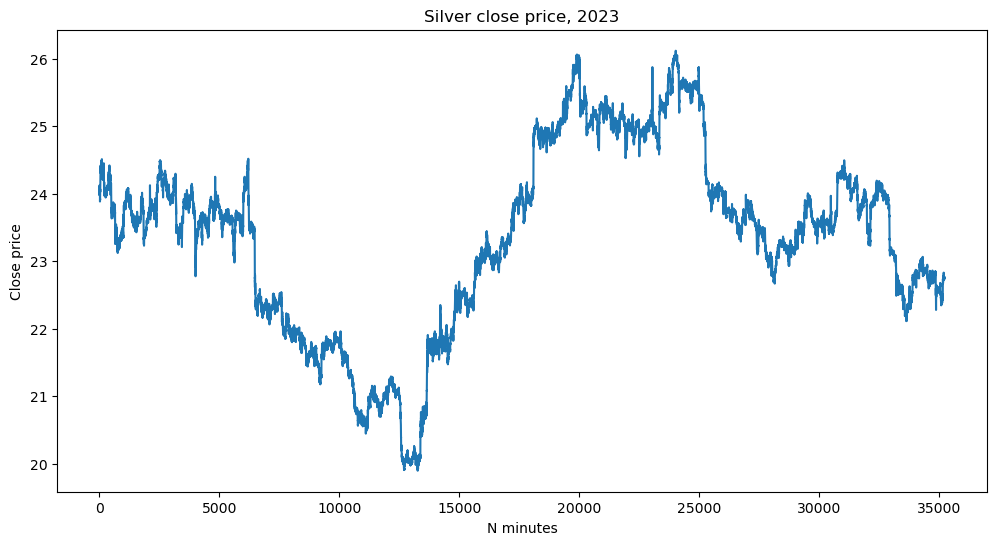

In [21]:
#this can be used for specific one-column
plt.figure(figsize=(12,6))
plt.plot(data['close_bid'])
plt.title('Silver close price, 2023')
plt.xlabel('N minutes')
plt.ylabel('Close price')
plt.show()

In [27]:
#Candlestick Chart
data_chart=data.set_index('Local_time_T',inplace=False)

In [28]:
data.columns

Index(['open_bid', 'high_bid', 'low_bid', 'close_bid', 'volume_bid',
       'volume_ask', 'volume_delta', 'volume_delta_abs', 'open_delta',
       'high_delta', 'low_delta', 'close_delta', 'Local_time_T'],
      dtype='object')

In [29]:

data_chart = data_chart.drop([
       'volume_ask', 'volume_delta', 'volume_delta_abs', 'open_delta',
       'high_delta', 'low_delta', 'close_delta'],axis=1)

In [40]:
data_chart

,open_bid,high_bid,low_bid,close_bid,volume_bid
Local_time_T,,,,,
2023-01-02 23:00:00+00:00,24.036,24.059,24.017,24.059,0.3480
2023-01-02 23:05:00+00:00,24.064,24.130,24.064,24.092,1.8458
2023-01-02 23:10:00+00:00,24.094,24.098,23.972,23.977,0.9030
2023-01-02 23:15:00+00:00,23.977,23.980,23.938,23.980,0.8940
2023-01-02 23:20:00+00:00,23.978,24.024,23.976,24.023,0.8880
...,...,...,...,...,...
2023-06-30 20:35:00+00:00,22.752,22.752,22.741,22.746,0.2752
2023-06-30 20:40:00+00:00,22.736,22.751,22.736,22.746,0.1410
2023-06-30 20:45:00+00:00,22.751,22.751,22.746,22.746,0.0690


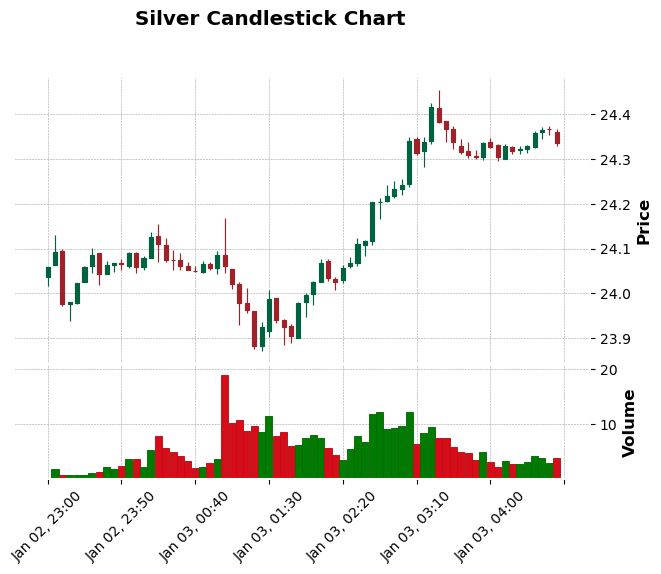

In [30]:
import mplfinance as mpf

data_chart.columns=['open', 'high', 'low', 'close','volume']
mpf.plot(data_chart.iloc[0:70], type='candle', style='charles',title='Silver Candlestick Chart',volume=True)

In [31]:
data_chart=[]

In [35]:
#create output(vector of answers) for normalisation
data['Y_High_Bid']=data['high_bid']
data['Y_Low_Ask']=data['low_bid']+data['low_delta']

DATA Normalisation


In [36]:
data_length= len(data)
data_length

35220

In [37]:
train_size=int(round(data_length*0.8,-3))
train_size

28000

In [38]:
train=data.iloc[:train_size]
train.shape

(28000, 15)

In [39]:
train.tail(2)

,open_bid,high_bid,low_bid,close_bid,volume_bid,volume_ask,volume_delta,volume_delta_abs,open_delta,high_delta,low_delta,close_delta,Local_time_T,Y_High_Bid,Y_Low_Ask
27998,23.049,23.091,23.049,23.067,4.7839,34.8313,30.0474,30.0474,0.03,0.03,0.03,0.03,2023-05-25 12:10:00+00:00,23.091,23.079
27999,23.074,23.080,23.029,23.039,5.0757,27.9602,22.8845,22.8845,0.03,0.03,0.03,0.03,2023-05-25 12:15:00+00:00,23.080,23.059


In [40]:
#Min max for price,volume and deltas
#Price
max_price=(train['high_bid']+train['high_delta']).max()
max_price

26.153

In [41]:
min_price=train['low_bid'].min()
min_price

19.888

In [42]:
#Volume
max_volume=max(max(train['volume_bid']), max(train['volume_ask']))
max_volume

365.6322

In [43]:
#Delta
max_delta = max(max(train['open_delta']), max(train['high_delta']), max(train['low_delta']), max(train['close_delta']))
max_delta

0.30900000000000105

In [44]:
max_delta=round(max_delta, 3)
max_delta

0.309

In [45]:
min_delta = min(min(train['open_delta']), min(train['high_delta']), min(train['low_delta']), min(train['close_delta']))
min_delta

0.0009999999999976694

In [46]:
min_delta=round(min_delta, 3)
min_delta

0.001

In [47]:
max_volume_delta= train['volume_delta'].max()
max_volume_delta

317.5858

In [48]:
min_volume_delta= train['volume_delta'].min()
min_volume_delta

-48.7912

In [49]:
max_volume_delta_abs= train['volume_delta_abs'].max()
max_volume_delta_abs

317.5858

In [50]:
min_volume_delta_abs= train['volume_delta_abs'].min()
min_volume_delta_abs

0.0

In [52]:
#Normalisation-Price
data['open_bid'] = ( data['open_bid'] - min_price ) / (max_price-min_price)
data['high_bid']  = ( data['high_bid']  - min_price ) / (max_price-min_price)
data['low_bid']   = ( data['low_bid']   - min_price ) / (max_price-min_price)
data['close_bid'] = ( data['close_bid'] - min_price ) / (max_price-min_price)
data['Y_High_Bid'] = ( data['Y_High_Bid'] - min_price ) / (max_price-min_price)
data['Y_Low_Ask']  = ( data['Y_Low_Ask']  - min_price ) / (max_price-min_price)


In [53]:
data['volume_ask']  = data['volume_ask'] / max_volume
data['volume_bid']  = data['volume_bid'] / max_volume

In [54]:
data['volume_delta'] = ( data['volume_delta'] - min_volume_delta ) / (max_volume_delta-min_volume_delta)

In [55]:
data['volume_delta_abs']  = data['volume_delta_abs'] / max_volume_delta_abs

In [56]:
#price deltas
data['open_delta']  = ( max_delta - data['open_delta'] )  / (max_delta-min_delta)
data['high_delta']  = ( max_delta - data['high_delta'] )  / (max_delta-min_delta)
data['low_delta']   = ( max_delta - data['low_delta'] )   / (max_delta-min_delta)
data['close_delta'] = ( max_delta - data['close_delta'] ) / (max_delta-min_delta)

In [57]:
data.head()

,open_bid,high_bid,low_bid,close_bid,volume_bid,volume_ask,volume_delta,volume_delta_abs,open_delta,high_delta,low_delta,close_delta,Local_time_T,Y_High_Bid,Y_Low_Ask
0,0.662091,0.665762,0.659058,0.665762,0.000952,0.000960,0.133180,0.000009,0.788961,0.788961,0.788961,0.788961,2023-01-02 23:00:00+00:00,0.665762,0.669593
1,0.666560,0.677095,0.666560,0.671030,0.005048,0.003159,0.131287,0.002175,0.905844,0.814935,0.905844,0.844156,2023-01-02 23:05:00+00:00,0.677095,0.671349
2,0.671349,0.671987,0.651875,0.652674,0.002470,0.002412,0.133115,0.000066,0.844156,0.840909,0.840909,0.840909,2023-01-02 23:10:00+00:00,0.671987,0.659856
3,0.652674,0.653152,0.646449,0.653152,0.002445,0.002445,0.133172,0.000000,0.844156,0.847403,0.847403,0.847403,2023-01-02 23:15:00+00:00,0.653152,0.654110
4,0.652833,0.660176,0.652514,0.660016,0.002429,0.002474,0.133217,0.000052,0.847403,0.844156,0.850649,0.840909,2023-01-02 23:20:00+00:00,0.660176,0.660016


In [58]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35220 entries, 0 to 35219
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   open_bid          35220 non-null  float64            
 1   high_bid          35220 non-null  float64            
 2   low_bid           35220 non-null  float64            
 3   close_bid         35220 non-null  float64            
 4   volume_bid        35220 non-null  float64            
 5   volume_ask        35220 non-null  float64            
 6   volume_delta      35220 non-null  float64            
 7   volume_delta_abs  35220 non-null  float64            
 8   open_delta        35220 non-null  float64            
 9   high_delta        35220 non-null  float64            
 10  low_delta         35220 non-null  float64            
 11  close_delta       35220 non-null  float64            
 12  Local_time_T      35220 non-null  datetime64[ns, UTC]
 13  Y

In [59]:
# #memory size reduction
# #columns_float =['open_bid', 'high_bid', 'low_bid', 'close_bid', 
#                 'volume_bid', 'volume_ask', 'volume_delta', 'volume_delta_abs', 
#                 'open_delta', 'high_delta', 'low_delta', 'close_delta',
#                 'Y_High_Bid', 'Y_Low_Ask']
# #columns_datetime =['New_day', 'New_week']

In [60]:
# #for column in columns_float:
#     data[column]= pd.to_numeric(data[column], downcast='float')
# #for column in columns_datetime:
#     data[column]=pd.to_numeric(data[column], downcast='integer')
# #data.info()


In [61]:
file_obj1 = open('SILVER_2023_normalised.csv', 'w')
data.to_csv('SILVER_2023_normalised.csv', encoding='utf-8', index=False)
file_obj1.close()

In [2]:
# lSTM

import tensorflow as tf
from tensorflow import keras

In [3]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint

In [4]:
np.random.seed(19)

In [5]:
data=pd.read_csv('SILVER_2023_normalised.csv',low_memory=False,sep=',')
data.head()

,open_bid,high_bid,low_bid,close_bid,volume_bid,volume_ask,volume_delta,volume_delta_abs,open_delta,high_delta,low_delta,close_delta,Local_time_T,Y_High_Bid,Y_Low_Ask
0,0.662091,0.665762,0.659058,0.665762,0.000952,0.000960,0.133180,0.000009,0.788961,0.788961,0.788961,0.788961,2023-01-02 23:00:00+00:00,0.665762,0.669593
1,0.666560,0.677095,0.666560,0.671030,0.005048,0.003159,0.131287,0.002175,0.905844,0.814935,0.905844,0.844156,2023-01-02 23:05:00+00:00,0.677095,0.671349
2,0.671349,0.671987,0.651875,0.652674,0.002470,0.002412,0.133115,0.000066,0.844156,0.840909,0.840909,0.840909,2023-01-02 23:10:00+00:00,0.671987,0.659856
3,0.652674,0.653152,0.646449,0.653152,0.002445,0.002445,0.133172,0.000000,0.844156,0.847403,0.847403,0.847403,2023-01-02 23:15:00+00:00,0.653152,0.654110
4,0.652833,0.660176,0.652514,0.660016,0.002429,0.002474,0.133217,0.000052,0.847403,0.844156,0.850649,0.840909,2023-01-02 23:20:00+00:00,0.660176,0.660016


In [6]:
data = data.drop(['Local_time_T'],axis=1)

<Figure size 1200x500 with 0 Axes>

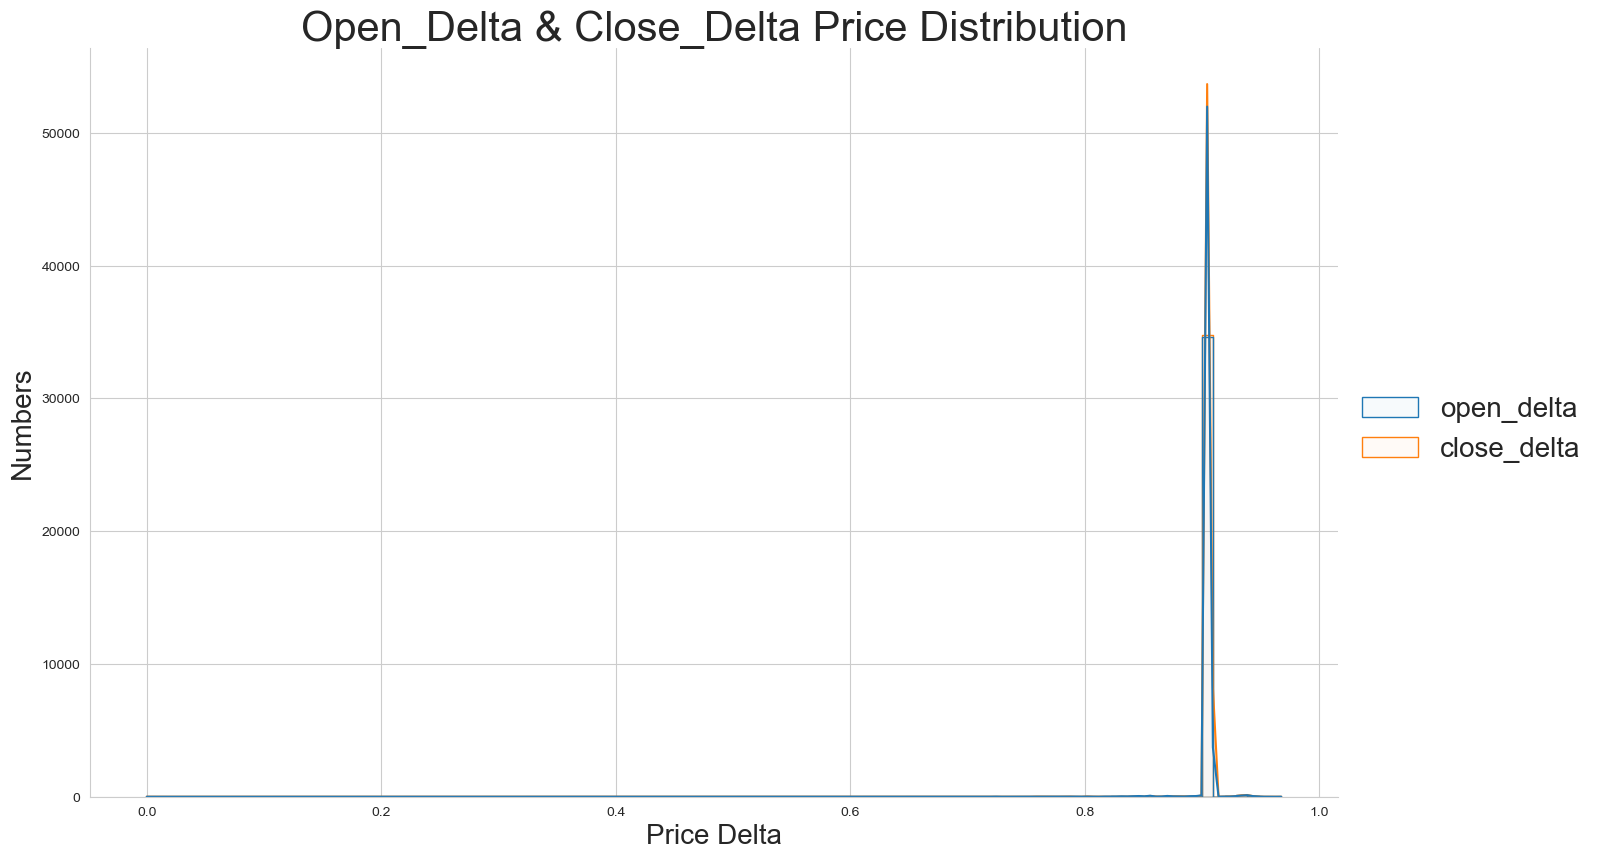

In [7]:
fig = plt.figure(figsize=(12, 5))
plt.rc('axes', titlesize= 30 ) 
sns.set_style('whitegrid')
sns.set_context(rc={'legend.fontsize': 20.0}) 

sns.displot( 
            data[['open_delta', 'close_delta']],
            height=8,
            aspect=1.7,
            kde=True,
            element="step",
            bins=100,
            alpha=0.03,          
                        
)

plt.title('Open_Delta & Close_Delta Price Distribution')
plt.xlabel('Price Delta', size= 20)
plt.ylabel('Numbers', size= 20)
plt.show()

In [8]:
n=data.shape[0]
n

35220

In [9]:
p=data.shape[1]
p

14

In [10]:
data['Y_High_Bid'] = data['high_bid']
data['Y_Low_Ask'] = data['low_bid'] + data['low_delta']

In [11]:
data_ax= data.drop(['Y_High_Bid', 'Y_Low_Ask'],axis=1)


In [12]:
data_ax.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35220 entries, 0 to 35219
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   open_bid          35220 non-null  float64
 1   high_bid          35220 non-null  float64
 2   low_bid           35220 non-null  float64
 3   close_bid         35220 non-null  float64
 4   volume_bid        35220 non-null  float64
 5   volume_ask        35220 non-null  float64
 6   volume_delta      35220 non-null  float64
 7   volume_delta_abs  35220 non-null  float64
 8   open_delta        35220 non-null  float64
 9   high_delta        35220 non-null  float64
 10  low_delta         35220 non-null  float64
 11  close_delta       35220 non-null  float64
dtypes: float64(12)
memory usage: 3.2 MB


In [13]:
data_ay= data[['Y_High_Bid', 'Y_Low_Ask']]

In [14]:
data_ay.shape

(35220, 2)

In [1]:
#price shifting
#remove 1 row for 5 minutes ahead prediction
data_ay=data_ay.shift(-1)

NameError: name 'data_ay' is not defined

In [ ]:
data_ay.tail()

In [17]:
# create new colomns: MIN_Lowest(Low_Ask) and MAX_Highest(High_Bid) prices of DURING NEXT 5 minutes

# Forward-looking window
indexer = pd.api.indexers.FixedForwardWindowIndexer(window_size=5)

data_ay['Y_High_Bid_5'] = data_ay['Y_High_Bid'].rolling(window=indexer).max()
data_ay['Y_Low_Ask_5']  = data_ay['Y_Low_Ask'].rolling(window=indexer).min()

In [18]:
data_ay.tail(10)

,Y_High_Bid,Y_Low_Ask
35210,0.457143,1.361231
35211,0.456983,1.331212
35212,0.456983,1.362029
35213,0.458579,1.334459
35214,0.459377,1.176275
35215,NaN,NaN
35216,NaN,NaN
35217,NaN,NaN
35218,NaN,NaN
35219,NaN,NaN


In [19]:
data_ay.head(10)

,Y_High_Bid,Y_Low_Ask
0,0.666081,1.511144
1,0.672466,1.524077
2,0.670870,1.523014
3,0.667837,1.568893
4,0.667199,1.569851
5,0.668476,1.570649
6,0.671030,1.571287
7,0.671189,1.569531
8,0.669753,1.570329
9,0.678053,1.574639


In [20]:
data_ay

,Y_High_Bid,Y_Low_Ask
0,0.666081,1.511144
1,0.672466,1.524077
2,0.670870,1.523014
3,0.667837,1.568893
4,0.667199,1.569851
...,...,...
35215,NaN,NaN
35216,NaN,NaN
35217,NaN,NaN
35218,NaN,NaN


In [21]:
for i in range(5):
        data_ay.drop(data_ay.shape[0]-1, axis=0, inplace=True)


In [22]:
for i in range(5):
    data_ax.drop(data_ax.shape[0]-1, axis=0, inplace=True)

In [23]:
#create input and output matrix
# Create inputs Numpy(for 3d tensor)

data_a = np.array(data_ax) 

with np.printoptions(precision=4):
    print("data_a:")
    print(data_a[:2,:])  
    print('\n')
    print(data_a[-2:,:]) 

print("numpy size: = ", data_a.shape)
print("type: ", data_a.dtype) 


data_a:
[[6.6209e-01 6.6576e-01 6.5906e-01 6.6576e-01 9.5178e-04 9.5998e-04
  1.3318e-01 9.4463e-06 7.8896e-01 7.8896e-01 7.8896e-01 7.8896e-01]
 [6.6656e-01 6.7709e-01 6.6656e-01 6.7103e-01 5.0482e-03 3.1589e-03
  1.3129e-01 2.1752e-03 9.0584e-01 8.1494e-01 9.0584e-01 8.4416e-01]]


[[0.4541 0.4563 0.4533 0.4555 0.0053 0.0095 0.1374 0.0049 0.9058 0.9058
  0.9058 0.9058]
 [0.4555 0.4571 0.4551 0.4571 0.001  0.004  0.1362 0.0034 0.9058 0.9058
  0.9058 0.9058]]
numpy size: =  (35215, 12)
type:  float64


In [24]:
data_ay

,Y_High_Bid,Y_Low_Ask
0,0.666081,1.511144
1,0.672466,1.524077
2,0.670870,1.523014
3,0.667837,1.568893
4,0.667199,1.569851
...,...,...
35210,0.457143,1.361231
35211,0.456983,1.331212
35212,0.456983,1.362029
35213,0.458579,1.334459


In [25]:
# Create outputs Numpy

data_y = np.array(data_ay) 

print("data_a:")
print(data_y[:3,:])  
print('\n')
print(data_y[-3:,:]) 

print("numpy size: = ", data_y.shape)
print("type: ", data_y.dtype) 

data_a:
[[0.6660814  1.51114416]
 [0.67246608 1.52407676]
 [0.67086991 1.52301386]]


[[0.45698324 1.36202931]
 [0.45857941 1.33445912]
 [0.45937749 1.17627512]]
numpy size: =  (35215, 2)
type:  float64


In [26]:
from tqdm import tqdm

In [27]:
n_small=30000
N=50
L=n_small-N
t=data_a.shape[1]
print('Size of a three-dimensional inputs tensor: ',L,N,t)

Size of a three-dimensional inputs tensor:  29950 50 12


In [28]:
# create imputs zeros 3D tensors with 'float32'

data_b = np.zeros( (L, N, t), dtype= 'float32' ) 

In [29]:
# create a two-dimensional zeros vector of answers - normalised the High_Bid and Low_Ask prices DURING next 5 minutes

Y = np.zeros((L, 2), dtype= 'float32') # We will predict two prices - normalised High_Bid and normalised Low_Ask

In [30]:
# fill the imputs 3D tansor (data_b) 
# and the array of answers Y 

#print('L = n - N = ', n-N, L)
print('L = n_small - N - 5 = ', n_small-N-5, L)
#for k in tqdm(range(L-1)):
for k in tqdm(range(L)):
    data_b[k, :, :] = data_a[k:k+N, :]   
                                          
    Y[k,0] = data_y[k+N-1,0]   # normalised Y_High_Bid - max 5 minutes future price
    Y[k,1] = data_y[k+N-1,1]   # normalised Y_Low_Ask -  min 5 minutes future price

print(k) # index value (for control)
    
print('data_b:', '\n', data_b)
print("Numpy size:        ", data_b.shape, '\n')

print( Y[:5,:])
print( Y[-10:,:])
print(      "Numpy size:         ", Y.shape)

L = n_small - N - 5 =  29945 29950


100%|██████████| 29950/29950 [00:00<00:00, 94317.43it/s] 

29949
data_b: 
 [[[0.66209096 0.6657622  0.6590583  ... 0.78896105 0.78896105 0.78896105]
  [0.66656023 0.677095   0.66656023 ... 0.8149351  0.90584415 0.84415585]
  [0.67134875 0.67198724 0.6518755  ... 0.84090906 0.84090906 0.84090906]
  ...
  [0.69114125 0.6964086  0.6901836  ... 0.90584415 0.90584415 0.90584415]
  [0.6936951  0.6970471  0.6914605  ... 0.91883117 0.90584415 0.90584415]
  [0.6952913  0.7122107  0.694174   ... 0.90584415 0.90584415 0.90584415]]

 [[0.66656023 0.677095   0.66656023 ... 0.8149351  0.90584415 0.84415585]
  [0.67134875 0.67198724 0.6518755  ... 0.84090906 0.84090906 0.84090906]
  [0.6526736  0.6531524  0.64644855 ... 0.8474026  0.8474026  0.8474026 ]
  ...
  [0.6936951  0.6970471  0.6914605  ... 0.91883117 0.90584415 0.90584415]
  [0.6952913  0.7122107  0.694174   ... 0.90584415 0.90584415 0.90584415]
  [0.7114126  0.7122107  0.7056664  ... 0.90584415 0.90584415 0.90584415]]

 [[0.67134875 0.67198724 0.6518755  ... 0.84090906 0.84090906 0.84090906]
  [0.6

In [31]:
# Control of the correctness of filling the array Y 
# (should show MAX of the normalised prices High_Bid and Low_Ask - during 5 next minutes(step) ahead)


import random

pp = random.randint(50, L) # (any number before 29950) - just to look at the middle of data_b
print('random int = ', pp)

print('data_b:', '\t\t','Y:')
print('Y_High_Bid ','\t\t','Y_High_Bid')

for i in range(15):
    print(data_b[pp+i,N-1,1], '\t\t', Y[pp+i,0])

random int =  2275
data_b: 		 Y:
Y_High_Bid  		 Y_High_Bid
0.6451716 		 0.6434158
0.64772546 		 0.64022344
0.64868313 		 0.6407023
0.64038306 		 0.62984836
0.6373504 		 0.62314445
0.6434158 		 0.6229848
0.64022344 		 0.6201117
0.6407023 		 0.6177175
0.62984836 		 0.6226656
0.62314445 		 0.62250596
0.6229848 		 0.6217079
0.6201117 		 0.6177175
0.6177175 		 0.6188348
0.6226656 		 0.62043095
0.62250596 		 0.6180367


In [32]:
#training
from sklearn.model_selection import train_test_split

In [33]:
X_train, X_test, y_train, y_test= train_test_split(data_b, Y, test_size=0.1,
                                                   shuffle=False, stratify= None, random_state=101)

In [34]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(26955, 50, 12)
(26955, 2)
(2995, 50, 12)
(2995, 2)


In [41]:
model=keras.Sequential([
    keras.layers.LSTM(100, activation='relu', input_shape=(50,12)),
    keras.layers.Dense(2)
])

In [42]:
print(model.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 100)            │        45,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           202 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,402 (177.35 KB)

 Trainable params: 45,402 (177.35 KB)

 Non-trainable params: 0 (0.00 B)

None


In [43]:
model.compile(optimizer="adam", loss="mse", metrics=["mae"])

In [44]:
# Early Stopping parameters

es = EarlyStopping(monitor='val_loss', mode='min', patience=5, verbose=1)
mc = ModelCheckpoint('best_model_LSTM_GOLD.keras', monitor='val_loss', mode='min', verbose=1, save_best_only=True)

In [45]:
history=model.fit(X_train, y_train, batch_size=20, epochs= 5,
                  validation_split=0.1, shuffle=True,
                  verbose=1, callbacks=[es, mc])

Epoch 1/5
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0515 - mae: 0.0791 
Epoch 1: val_loss improved from None to 0.00024, saving model to best_model_LSTM_GOLD.keras
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 40s 28ms/step - loss: 0.0096 - mae: 0.0249 - val_loss: 2.3779e-04 - val_mae: 0.0083
Epoch 2/5
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 2.2667e-04 - mae: 0.0098 
Epoch 2: val_loss did not improve from 0.00024
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 34s 28ms/step - loss: 2.5433e-04 - mae: 0.0100 - val_loss: 5.2185e-04 - val_mae: 0.0171
Epoch 3/5
1212/1213 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 2.4773e-04 - mae: 0.0100 
Epoch 3: val_loss did not improve from 0.00024
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 34s 28ms/step - loss: 2.5640e-04 - mae: 0.0101 - val_loss: 2.5060e-04 - val_mae: 0.0093
Epoch 4/5
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 2.5545e-04 - mae: 0.0094 
Epoch 4: val_loss improved from 0.00024 to 0.00020, saving model to best_model_LSTM_GOLD.keras
1213/1213 ━━━━━━━━

In [46]:
LSTM_saved_best_model= keras.models.load_model('best_model_LSTM_GOLD.keras')

In [47]:
#testing
scores = LSTM_saved_best_model.evaluate(X_test, y_test, verbose=1)

94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 3.2158e-04 - mae: 0.0072


In [48]:
scores

[0.0003215802425984293, 0.007205964997410774]

In [49]:
print("Mean squared error (mse): %.9f " % (scores[0]))
print("Mean absolute error (mae): %.9f " % (scores[1]))

Mean squared error (mse): 0.000321580 
Mean absolute error (mae): 0.007205965 


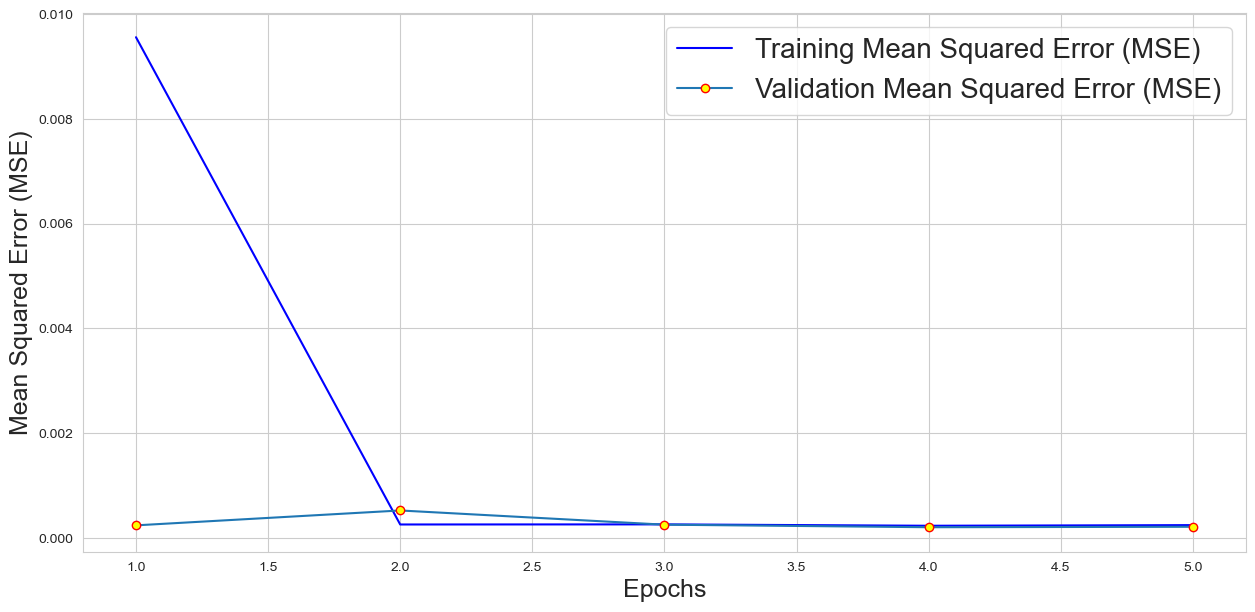

In [50]:
#MSE graph(training + epoch)

history_dict = history.history

mse_values = history_dict['loss']
val_mse_values = history_dict['val_loss']

epochs = range(1, len(mse_values) + 1)
plt.figure(num=1, figsize=(15,7))
plt.plot(epochs, mse_values, 'b', label='Training Mean Squared Error (MSE)')
plt.plot(epochs, val_mse_values, marker='o', markeredgecolor='red', markerfacecolor='yellow', label='Validation Mean Squared Error (MSE)')
plt.xlabel('Epochs', size=18)
plt.ylabel('Mean Squared Error (MSE)', size=18)
plt.legend()
plt.show()

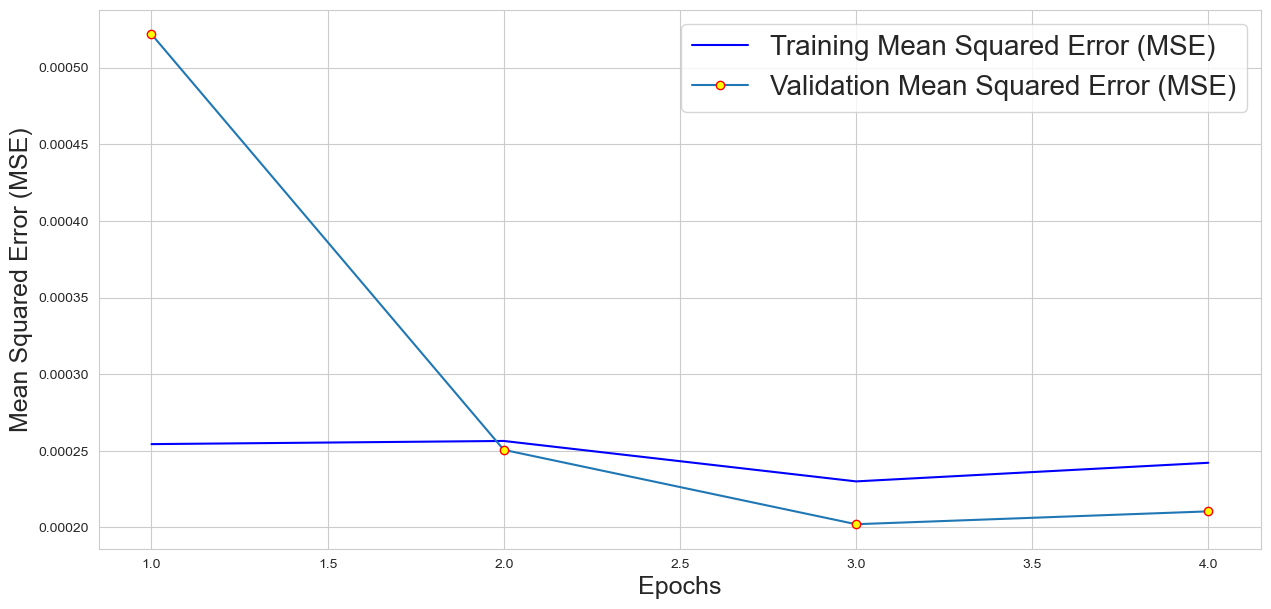

In [51]:
#training MSE and Validation MSE

history_dict = history.history

mse_values = history_dict['loss'][1:]
val_mse_values = history_dict['val_loss'][1:]

epochs = range(1, len(mse_values) + 1)
plt.figure(num=1, figsize=(15,7))
plt.plot(epochs, mse_values, 'b', label='Training Mean Squared Error (MSE)')
plt.plot(epochs, val_mse_values, marker='o', markeredgecolor='red', markerfacecolor='yellow', label='Validation Mean Squared Error (MSE)')
plt.xlabel('Epochs', size=18)
plt.ylabel('Mean Squared Error (MSE)', size=18)
plt.legend()
plt.show()

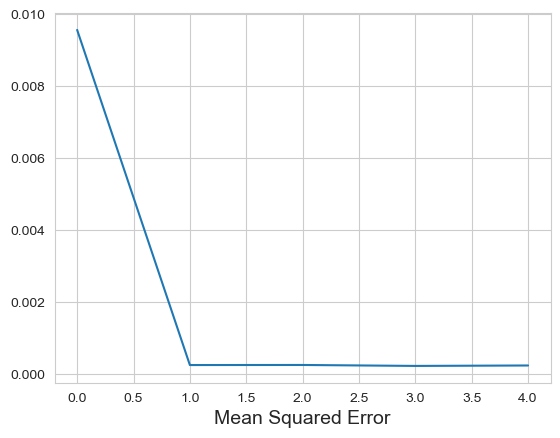

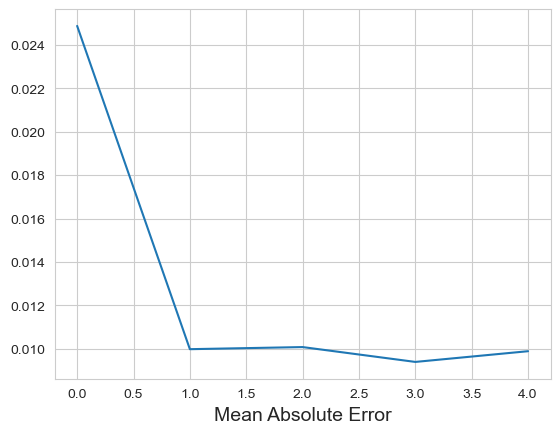

In [54]:
#mse
plt.plot(history.history['loss'])
plt.xlabel('Mean Squared Error', size=14)
plt.show()

#mae
plt.plot(history.history['mae'])
plt.xlabel('Mean Absolute Error', size=14)
plt.show()

In [56]:
#predicted 5 min ahead

pred=LSTM_saved_best_model(X_test)
print(pred)

tf.Tensor(
[[0.63056767 1.5228413 ]
 [0.63111174 1.5244039 ]
 [0.63161093 1.5259457 ]
 ...
 [0.5892318  1.4879    ]
 [0.5888224  1.4875208 ]
 [0.5885553  1.487387  ]], shape=(2995, 2), dtype=float32)


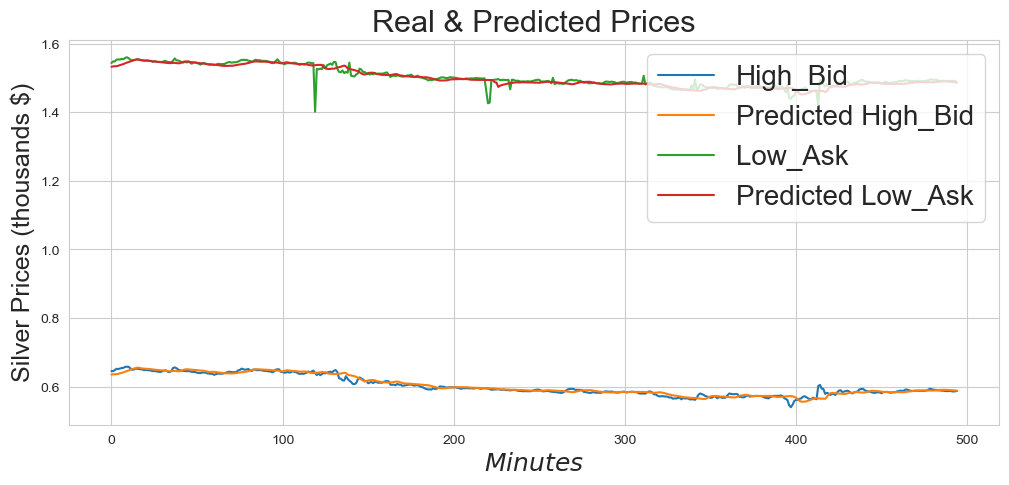

In [63]:
#price chart
N1=2500  # The first minute for the chart  
LL = 500  # Duration (in minutes) for the chart
N2=N1+LL  # the last minute for the chart

plt.ion()
fig = plt.figure(figsize=(12,5))  

ax1 = fig.add_subplot(111)
line1, = ax1.plot(y_test[N1:N2,0], label='High_Bid')
line2, = ax1.plot(pred[N1:N2,0], label='Predicted High_Bid')
line3, = ax1.plot(y_test[N1:N2,1], label='Low_Ask')
line4, = ax1.plot(pred[N1:N2,1], label='Predicted Low_Ask')

plt.title('Real & Predicted Prices', size=22)
plt.ylabel('Silver Prices (thousands $)', size=18)
plt.xlabel('$Minutes$', size=18)
plt.legend(loc='upper right') 

plt.show()


In [64]:
max_price= 26.153
min_price= 19.888
average_price=(max_price+min_price)/2



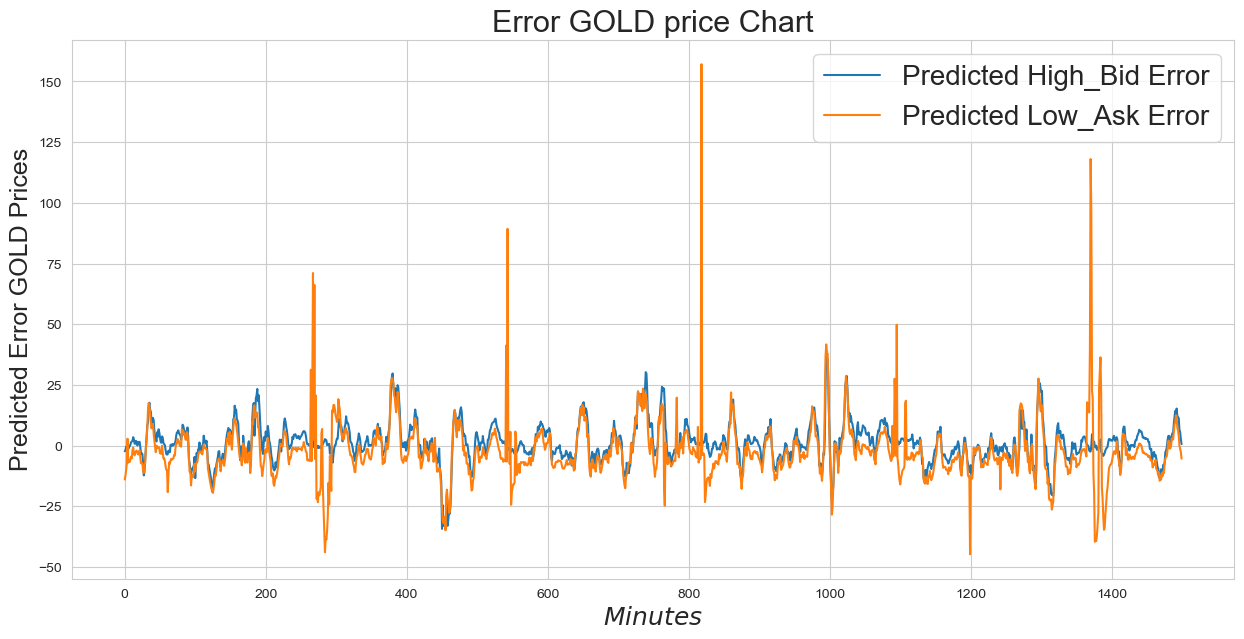

In [67]:
#Error chart
N1=0  # The first minute for the chart  
LL = 1500  # leigt (in minutes) for the chart
N2=N1+LL  # the last minute for the chart
# N2 should be < len(pred)

plt.ion()
fig = plt.figure(figsize=(15,7))  

ax1 = fig.add_subplot(111)

# in $ (absolute price)
a = (pred[N1:N2,0] - y_test[N1:N2,0]) *1000
b = (pred[N1:N2,1] - y_test[N1:N2,1]) *1000

# in %
#a = (pred[N1:N2,0] - y_test[N1:N2,0]) *1000/ average_price *100
#b = (pred[N1:N2,1] - y_test[N1:N2,1]) *1000/ average_price *100


line1, = ax1.plot(a, label='Predicted High_Bid Error')
line2, = ax1.plot(b, label='Predicted Low_Ask Error')

plt.title('Error GOLD price Chart', size=22)
plt.ylabel('Predicted Error GOLD Prices', size=18)
plt.xlabel('$Minutes$', size=18)
plt.legend(loc='upper right') 
plt.show()
